In [1]:
import pandas as pd
import numpy as np


In [4]:
df = pd.read_csv(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data\ds_salaries.csv")

# Week 1 Observations

- Dataset contains 607 records and 12 columns
- Covers years 2020 to 2022
- No missing values found
- Majority jobs are remote/hybrid
- Salary ranges from 2,800 USD to 600,000 USD
- Data includes multiple job roles and countries


In [7]:
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [8]:
df = df.drop(columns=["Unnamed: 0"])


In [9]:
df.columns


Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

- Rename

In [10]:
df = df.rename(columns={
    "work_year": "year",
    "experience_level": "experience",
    "employment_type": "job_type",
    "salary_in_usd": "salary_usd",
    "employee_residence": "employee_country",
    "company_location": "company_country"
})


In [11]:
df.columns


Index(['year', 'experience', 'job_type', 'job_title', 'salary',
       'salary_currency', 'salary_usd', 'employee_country', 'remote_ratio',
       'company_country', 'company_size'],
      dtype='object')

- Convert Codes to Full Words

In [12]:
df["experience"] = df["experience"].replace({
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive"
})


In [13]:
df["job_type"] = df["job_type"].replace({
    "FT": "Full Time",
    "PT": "Part Time",
    "CT": "Contract"
})


In [14]:
df["company_size"] = df["company_size"].replace({
    "S": "Small",
    "M": "Medium",
    "L": "Large"
})


- Check Duplicates + Missing Values

In [16]:
df.duplicated().sum()


42

In [17]:
df = df.drop_duplicates()


In [18]:
df.isnull().sum()


year                0
experience          0
job_type            0
job_title           0
salary              0
salary_currency     0
salary_usd          0
employee_country    0
remote_ratio        0
company_country     0
company_size        0
dtype: int64

- Save Clean Data

In [19]:
df.to_csv(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\dataclean_jobs_data.csv", index=False)

In [20]:
import os

os.getcwd()


'C:\\Users\\NALUBALA ARJUN\\Dropbox\\OneDrive\\main_asritha\\Job_Market_Project\\notebooks'

In [21]:
import os
os.listdir(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data")

['ds_salaries.csv']

In [22]:
df.to_csv(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data\clean_jobs_data.csv",index=False)
print("Clean file saved successfully")

Clean file saved successfully


In [23]:
import os
os.listdir(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data")

['clean_jobs_data.csv', 'ds_salaries.csv']

# Week 2: Data Cleaning Summary

## Tasks Completed
- Removed unnecessary column (Unnamed: 0)
- Renamed columns for better readability
- Converted coded values into meaningful labels
- Removed duplicate records (42 rows)
- Verified missing values (no nulls found)
- Saved cleaned dataset

## Data Cleaning Actions
- Standardized experience levels (Entry, Mid, Senior, Executive)
- Standardized employment types (Full Time, Part Time, Contract)
- Standardized company size (Small, Medium, Large)
- Ensured consistent salary format using USD

## Output
- Generated cleaned file: clean_jobs_data.csv
- Dataset ready for analysis

## Learning Outcome
- Understood importance of data quality
- Learned how to handle duplicates and formatting issues
- Prepared data for Exploratory Data Analysis (EDA)


# WEEK 3 — Analysis & Visualization

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data\clean_jobs_data.csv")

In [27]:
df["job_title"].value_counts().head(10)


job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Big Data Engineer               8
Machine Learning Scientist      8
Principal Data Scientist        7
Name: count, dtype: int64

- Plot Bar Chart


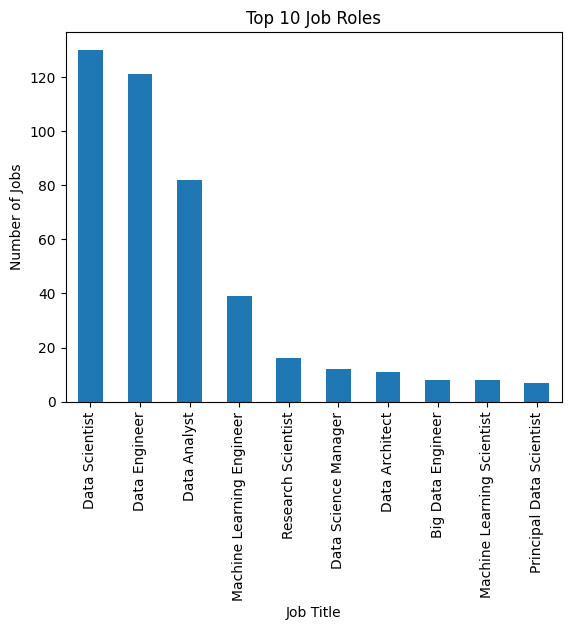

In [43]:
df["job_title"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Job Roles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.savefig(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\visuals\top_roles.png")
plt.show()


- Salary Analysis by Experience

- Average Salary

In [44]:
df.groupby("experience")["salary_usd"].mean()


experience
Entry Level      61643.318182
Executive       199392.038462
Mid Level        87792.995192
Senior Level    138374.880658
Name: salary_usd, dtype: float64

- Boxplot

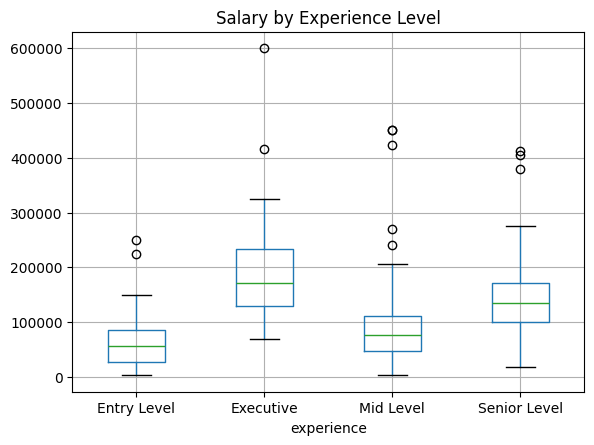

In [42]:
df.boxplot(column="salary_usd", by="experience")
plt.title("Salary by Experience Level")
plt.suptitle("")
plt.savefig(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\visuals\Salary_by_Experience_Level.png")
plt.show()


- Remote Job Analysis

In [33]:
df["remote_ratio"].value_counts()


remote_ratio
100    346
0      121
50      98
Name: count, dtype: int64

- Pie Chart

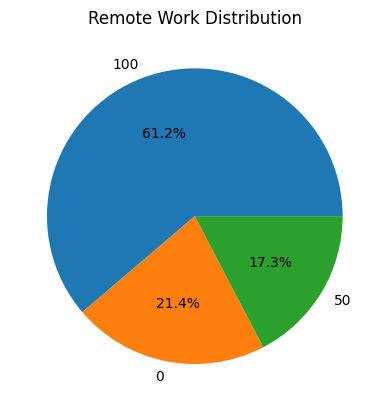

In [45]:
df["remote_ratio"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Remote Work Distribution")
plt.ylabel("")
plt.savefig(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\visuals\remote_jobs.png")
plt.show()


- Country-wise Jobs

- Top Countries

In [35]:
df["company_country"].value_counts().head(10)


company_country
US    318
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
Name: count, dtype: int64

- Plot

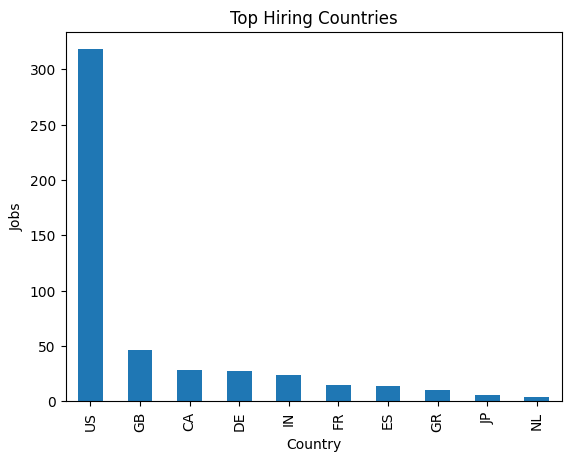

In [36]:
df["company_country"].value_counts().head(10).plot(kind="bar")
plt.title("Top Hiring Countries")
plt.xlabel("Country")
plt.ylabel("Jobs")
plt.show()


- Company Size vs Salary

- Company Size vs Salary

In [37]:
df.groupby("company_size")["salary_usd"].mean()


company_size
Large     118213.880829
Medium    114807.079310
Small      77872.097561
Name: salary_usd, dtype: float64

- Save All Graphs

In [39]:
plt.savefig(r"C:\Users\NALUBALA ARJUN\Dropbox\OneDrive\main_asritha\Job_Market_Project\data\salary_experience.png")


<Figure size 640x480 with 0 Axes>

# Week 3: Exploratory Data Analysis & Visualization

## Objective
The objective of this phase was to analyze the cleaned job market dataset and identify trends related to job roles, salaries, experience levels, locations, and remote work opportunities.

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Analysis Performed

### 1. Job Role Analysis
- Identified the top 10 most frequent job roles.
- Observed that roles such as Data Scientist, Data Analyst, and Machine Learning Engineer are in highest demand.

### 2. Salary Analysis by Experience Level
- Calculated average salaries for Entry, Mid, Senior, and Executive levels.
- Found that Senior and Executive roles receive significantly higher salaries.
- Entry-level roles have lower but competitive starting salaries.

### 3. Remote Work Analysis
- Analyzed the distribution of remote, hybrid, and on-site jobs.
- Majority of roles offer remote or hybrid work options.
- Indicates growing flexibility in the data science job market.

### 4. Country-wise Job Distribution
- Identified top hiring countries.
- United States, India, and European countries dominate the job market.
- Shows global demand for data professionals.

### 5. Company Size vs Salary
- Compared average salaries across Small, Medium, and Large companies.
- Medium and Large companies generally offer higher compensation.
- Small companies provide opportunities but with lower average salaries.

## Visualizations Created
- Bar chart for top job roles
- Boxplot for salary vs experience
- Pie chart for remote work distribution
- Bar chart for top hiring countries
- Bar chart for salary by company size

## Key Insights
- Data Scientist and Data Analyst roles are most in demand.
- Salary increases significantly with experience.
- Remote work is a major trend in the industry.
- Large and medium companies provide better salary packages.
- The job market is highly competitive and global.

## Learning Outcome
- Learned how to perform exploratory data analysis using Python.
- Improved skills in interpreting visual patterns.
- Gained experience in converting raw data into meaningful insights.
- Developed confidence in presenting analytical findings.

## Conclusion
The Week 3 analysis successfully revealed important trends in the data job market. These insights can help job seekers understand industry expectations and plan their career paths accordingly.


# WEEK 4 — Final Report + Portfolio Setup

- Organize Project (Make It Look Professional)

In [ ]:
plt.savefig("path/filename.png")
